In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
aligned_preds = pd.read_csv('/ibex/user/sotoorda/LLM_project/benchmarking/aligned_model_predictions.csv')
consensus_preds = pd.read_csv('/ibex/user/sotoorda/LLM_project/LLM_model/results/consensus_per_cell_results.csv')

model_configs = [
    ("CellTypist", aligned_preds, "Ground_truth", "CellTypist"),
    ("Random Forest", aligned_preds, "Ground_truth", "RandomForest"),
    ("Seurat", aligned_preds, "Ground_truth", "Seurat"),
    ("scGPT", aligned_preds, "Ground_truth", "scGPT_prediction"),
    ("Consensus", consensus_preds, "Ground_truth", "Consensus_label"),
]

In [48]:
# Define lineage mapping and colors
lineage_map = {
    "HSC": "Stem",
    "MPP": "Stem",
    "CLP": "Lymphoid",
    "ProB": "Lymphoid",
    "PreB": "Lymphoid",
    "GMP": "Myeloid",
    "MDP": "Myeloid",
    "Eo/B/Mast": "Myeloid",
    "MEP": "Erythroid",
    "ERP": "Erythroid",
    "MKP": "Erythroid",
    "CD8 T-cell": "Lymphoid",
    "Follicular B cell": "Lymphoid",
    "Plasma Cell": "Lymphoid",
    "Immature-Neutrophil": "Lymphoid",
    "Dendritic Cell": "Myeloid",
    "Pre-Dendritic": "Myeloid",
    "Monocyte": "Myeloid",
    "Neutrophil": "Myeloid",
    "Eosinophil": "Myeloid",
    "Granulocytic-UNK": "Myeloid",
    "Early-Erythroblast": "Erythroid",
    "Erythroblast": "Erythroid",
    "Platelet": "Erythroid",
    "pre-PC": "Lymphoid",
    "Stromal": "Stromal",
    "NK cells": "Lymphoid",
    "Naive T-cell": "Lymphoid"
}

lineage_colors = {
    "Stem": "black",
    "Lymphoid": "#b5838d",
    "Myeloid": "#6a994e",
    "Erythroid": "#d90429",
    "Stromal": "#ffb703"
}

lineage_order = ["Stem", "Lymphoid", "Myeloid", "Erythroid", "Stromal"]

In [49]:
# Helper functions
def get_label_colors(labels, lineage_map, lineage_colors):
    colors = []
    for lab in labels:
        lineage = lineage_map.get(lab, None)
        if lineage is None:
            colors.append("black")
        else:
            colors.append(lineage_colors.get(lineage, "black"))
    return colors


def sort_labels_by_lineage(labels, lineage_map, lineage_order):
    def sort_key(label):
        lineage = lineage_map.get(label, "Unknown")
        try:
            lineage_idx = lineage_order.index(lineage)
        except ValueError:
            lineage_idx = len(lineage_order)
        return (lineage_idx, label)

    return sorted(labels, key=sort_key)


def reorder_lineage_block(labels, gt_labels):
    """Within a lineage block, move labels shared with GT to the top."""
    shared = [l for l in labels if l in gt_labels]
    not_shared = [l for l in labels if l not in gt_labels]
    return shared + not_shared


def build_pred_order(pred_labels, gt_labels, lineage_map, lineage_order):
    final_pred_order = []

    for lineage in lineage_order:
        block_labels = [l for l in pred_labels if lineage_map.get(l) == lineage]
        block_labels_sorted = reorder_lineage_block(block_labels, gt_labels)
        final_pred_order.extend(block_labels_sorted)

    unknown_preds = [l for l in pred_labels if l not in final_pred_order]
    final_pred_order.extend(unknown_preds)
    return final_pred_order


def build_row_normalized_cm(df, true_col, pred_col, row_order, col_order):
    y_true = df[true_col].astype(str)
    y_pred = df[pred_col].astype(str)

    cm_df = pd.crosstab(
        pd.Categorical(y_true, categories=row_order),
        pd.Categorical(y_pred, categories=col_order),
        dropna=False
    )

    # Per-class recall: normalize rows, with safe handling of zero rows
    return cm_df.div(cm_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

In [50]:
# Build global row/column orders so all subplots can share the same axes
all_gt_labels = set()
all_pred_labels = set()

for _, df_model, true_col, pred_col in model_configs:
    all_gt_labels.update(df_model[true_col].astype(str).unique())
    all_pred_labels.update(df_model[pred_col].astype(str).unique())

sorted_rows = sort_labels_by_lineage(list(all_gt_labels), lineage_map, lineage_order)
final_pred_order = build_pred_order(
    sort_labels_by_lineage(list(all_pred_labels), lineage_map, lineage_order),
    set(sorted_rows),
    lineage_map,
    lineage_order
)

row_colors = get_label_colors(sorted_rows, lineage_map, lineage_colors)
col_colors = get_label_colors(final_pred_order, lineage_map, lineage_colors)

In [51]:
# Build confusion matrices for all five methods using shared row/column order
cm_results = {}

for model_name, df_model, true_col, pred_col in model_configs:
    cm_results[model_name] = build_row_normalized_cm(
        df_model,
        true_col,
        pred_col,
        sorted_rows,
        final_pred_order
    )

# Keep one matrix exposed for quick inspection if needed
cm_final = cm_results["Consensus"]
cm_final

col_0,HSC,MPP,CLP,PreB,ProB,CD8 T-cell,Follicular B cell,Immature-Neutrophil,NK cells,Naive T-cell,...,Monocyte,Neutrophil,Pre-Dendritic,ERP,MEP,Early-Erythroblast,Erythroblast,MKP,Platelet,Stromal
row_0,,,,,,,,,,,,,,,,,,,,,
HSC,0.863744,0.007083,0.012816,0.000000,0.002024,0.000000,0.000675,0.0,0.012142,0.0,...,0.000337,0.004047,0.000000,0.000000,0.006745,0.000000,0.000337,0.000000,0.003710,0.001349
MPP,0.555108,0.254032,0.046371,0.002016,0.027554,0.000672,0.000000,0.0,0.004032,0.0,...,0.001344,0.000672,0.000000,0.001344,0.005376,0.000000,0.000000,0.000000,0.000000,0.002016
CLP,0.272563,0.138989,0.223827,0.000000,0.086643,0.014440,0.012635,0.0,0.023466,0.0,...,0.001805,0.000000,0.000000,0.000000,0.000000,0.000000,0.003610,0.000000,0.005415,0.001805
PreB,0.000000,0.001075,0.029749,0.268817,0.575986,0.000358,0.000358,0.0,0.000358,0.0,...,0.000358,0.000000,0.000358,0.000358,0.000358,0.000000,0.001792,0.000000,0.000717,0.000358
ProB,0.001890,0.000302,0.007032,0.000151,0.017844,0.000832,0.000227,0.0,0.000605,0.0,...,0.000151,0.000000,0.000076,0.000076,0.000076,0.000000,0.000756,0.000000,0.000000,0.000151
Eo/B/Mast,0.021834,0.065502,0.061135,0.000000,0.000000,0.000000,0.000000,0.0,0.039301,0.0,...,0.000000,0.008734,0.000000,0.131004,0.030568,0.000000,0.000000,0.000000,0.008734,0.000000
GMP,0.025468,0.185019,0.077903,0.068914,0.023221,0.003745,0.000749,0.0,0.017978,0.0,...,0.000000,0.002247,0.002247,0.000749,0.002247,0.000000,0.005243,0.000000,0.008240,0.006742
MDP,0.009091,0.384848,0.100000,0.006061,0.033333,0.000000,0.006061,0.0,0.009091,0.0,...,0.003030,0.003030,0.009091,0.000000,0.000000,0.000000,0.009091,0.000000,0.012121,0.006061
ERP,0.003472,0.003472,0.062500,0.000000,0.000000,0.000000,0.000000,0.0,0.017361,0.0,...,0.000000,0.013889,0.000000,0.670139,0.065972,0.006944,0.006944,0.017361,0.000000,0.003472


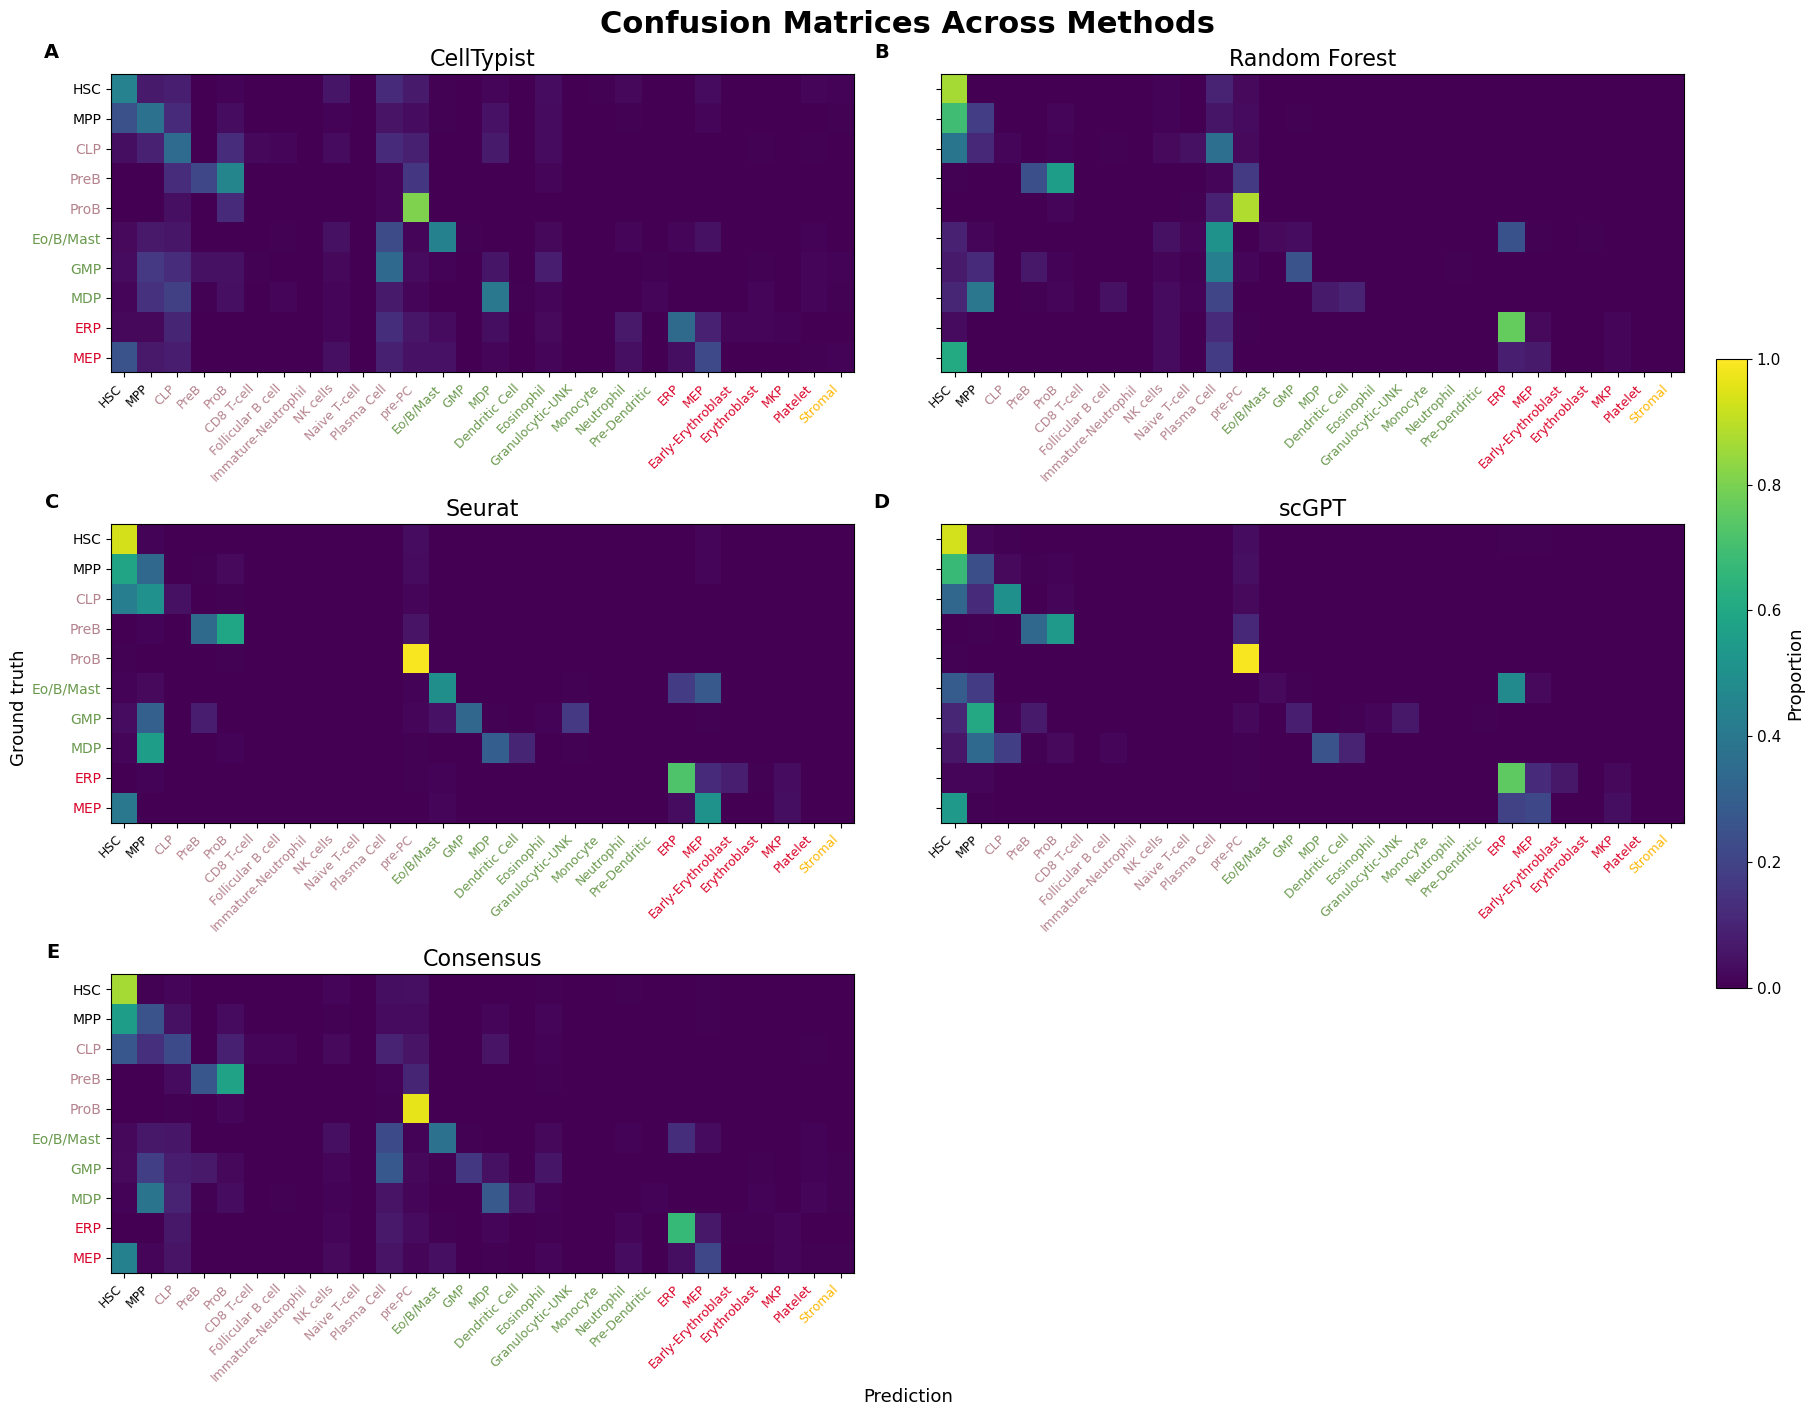

In [59]:
# Journal-style panel layout: 2 columns x 3 rows (5 matrices + 1 empty slot)
fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=True, sharey=True, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)
axes_flat = axes.flatten()
panel_letters = ["A", "B", "C", "D", "E"]

im = None
for i, (model_name, _, _, _) in enumerate(model_configs):
    ax = axes_flat[i]
    cm_plot = cm_results[model_name]

    im = ax.imshow(cm_plot.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)

    # Panel label + model title
    ax.text(
        -0.07, 1.04, panel_letters[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='bottom',
        ha='right'
    )
    ax.set_title(model_name, fontsize=16, pad=6)

    # Ticks and tick labels
    ax.set_xticks(range(len(final_pred_order)))
    ax.set_yticks(range(len(sorted_rows)))
    ax.set_xticklabels(final_pred_order, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(sorted_rows, fontsize=10)

    # Show x tick labels on all panels; show y tick labels only on left column for unified layout
    ax.tick_params(axis='x', labelbottom=True)
    if i % 2 == 0:
        ax.tick_params(axis='y', labelleft=True)
    else:
        ax.tick_params(axis='y', labelleft=False)

    # Lineage-colored tick labels
    for tick, color in zip(ax.get_yticklabels(), row_colors):
        tick.set_color(color)
    for tick, color in zip(ax.get_xticklabels(), col_colors):
        tick.set_color(color)

# Hide the 6th (unused) subplot
axes_flat[-1].axis('off')

# Unified axis titles for the whole figure
fig.supxlabel("Prediction", fontsize=13)
fig.supylabel("Ground truth", fontsize=13)

# Single shared legend/colorbar for all subplots
cbar = fig.colorbar(im, ax=axes_flat[:5], fraction=0.02, pad=0.02)
cbar.set_label("Proportion", fontsize=13)
cbar.ax.tick_params(labelsize=11)

fig.suptitle("Confusion Matrices Across Methods", fontsize=22, fontweight='bold')

plt.savefig(
    "/ibex/user/sotoorda/LLM_project/Additional_visualization/cm_panel_5_models.pdf",
    dpi=300,
    format='pdf',
    bbox_inches='tight'
)
plt.show()